In [59]:
!pip install timm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [61]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [62]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [63]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [64]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [65]:
class TransUNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # ViT Encoder
        self.encoder = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            num_classes=0
        )

        # CNN Decoder
        self.conv = nn.Sequential(
            nn.Conv2d(768, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # 🔥 EVERYTHING MUST BE INDENTED HERE

        x = self.encoder.forward_features(x)  # [B, N, C]

        B, N, C = x.shape

        # ✅ Remove CLS token
        x = x[:, 1:, :]

        # ✅ Reshape
        h = w = int(np.sqrt(x.shape[1]))
        x = x.permute(0, 2, 1).reshape(B, C, h, w)

        x = self.conv(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [66]:
model = TransUNetClassifier(num_classes=len(class_names))
model = model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [67]:
images, _ = next(iter(train_loader))
images = images.to(device)

outputs = model(images)
print(outputs.shape)

torch.Size([32, 4])


In [68]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [69]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [70]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.numpy())

        val_f1 = f1_score(val_labels, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_transunet.pth")

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val F1: {val_f1:.4f}")

    model.load_state_dict(torch.load("best_transunet.pth"))
    return model

In [71]:
model = train_model(model, train_loader, val_loader, epochs=10)

Epoch 1 | Train Acc: 0.7794 | Val F1: 0.7338
Epoch 2 | Train Acc: 0.8193 | Val F1: 0.8282
Epoch 3 | Train Acc: 0.8370 | Val F1: 0.8178
Epoch 4 | Train Acc: 0.8476 | Val F1: 0.8240
Epoch 5 | Train Acc: 0.8512 | Val F1: 0.8434
Epoch 6 | Train Acc: 0.8573 | Val F1: 0.8569
Epoch 7 | Train Acc: 0.8672 | Val F1: 0.8362
Epoch 8 | Train Acc: 0.8647 | Val F1: 0.7786
Epoch 9 | Train Acc: 0.8696 | Val F1: 0.8012
Epoch 10 | Train Acc: 0.8831 | Val F1: 0.8626


In [72]:
for param in model.parameters():
    param.requires_grad = True

In [73]:
model = train_model(model, train_loader, val_loader, epochs=20)

Epoch 1 | Train Acc: 0.8107 | Val F1: 0.7557
Epoch 2 | Train Acc: 0.8515 | Val F1: 0.8526
Epoch 3 | Train Acc: 0.8589 | Val F1: 0.8653
Epoch 4 | Train Acc: 0.8669 | Val F1: 0.8426
Epoch 5 | Train Acc: 0.8775 | Val F1: 0.5659
Epoch 6 | Train Acc: 0.8865 | Val F1: 0.8774
Epoch 7 | Train Acc: 0.8924 | Val F1: 0.8592
Epoch 8 | Train Acc: 0.8985 | Val F1: 0.8576
Epoch 9 | Train Acc: 0.8988 | Val F1: 0.8423
Epoch 10 | Train Acc: 0.9274 | Val F1: 0.9034
Epoch 11 | Train Acc: 0.9430 | Val F1: 0.9100
Epoch 12 | Train Acc: 0.9536 | Val F1: 0.9248
Epoch 13 | Train Acc: 0.9626 | Val F1: 0.9143
Epoch 14 | Train Acc: 0.9667 | Val F1: 0.8979
Epoch 15 | Train Acc: 0.9679 | Val F1: 0.9239
Epoch 16 | Train Acc: 0.9804 | Val F1: 0.9330
Epoch 17 | Train Acc: 0.9858 | Val F1: 0.9359
Epoch 18 | Train Acc: 0.9898 | Val F1: 0.9342
Epoch 19 | Train Acc: 0.9890 | Val F1: 0.9271
Epoch 20 | Train Acc: 0.9891 | Val F1: 0.9392


In [74]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      1.00       405
             Normal       0.99      0.98      0.98       405
Pneumonia-Bacterial       0.87      0.87      0.87       405
    Pneumonia-Viral       0.86      0.85      0.86       405

           accuracy                           0.93      1620
          macro avg       0.93      0.93      0.93      1620
       weighted avg       0.93      0.93      0.93      1620



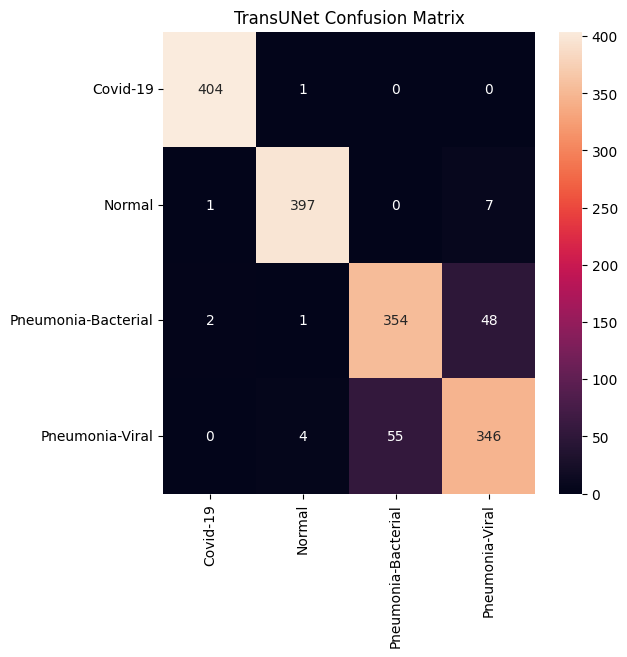

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("TransUNet Confusion Matrix")
plt.show()

In [76]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [77]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [78]:
num_classes = all_probs.shape[1]

y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

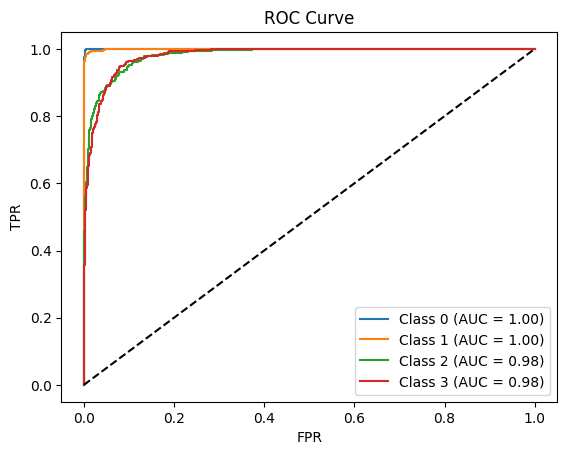

Macro AUC: 0.9904414977391658


In [79]:
plt.figure()

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

# overall score
print("Macro AUC:", roc_auc_score(y_true_bin, all_probs, multi_class='ovr'))

In [80]:
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

In [81]:
target_layer = None
for name, module in reversed(list(model.named_modules())):
    if isinstance(module, torch.nn.Conv2d):
        target_layer = module
        print("Using layer:", name)
        break

Using layer: conv.3


In [82]:
cam = GradCAM(model=model, target_layers=[target_layer])

image, label = next(iter(test_loader))
input_tensor = image[0:1].to(device)

targets = [ClassifierOutputTarget(label[0].item())]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

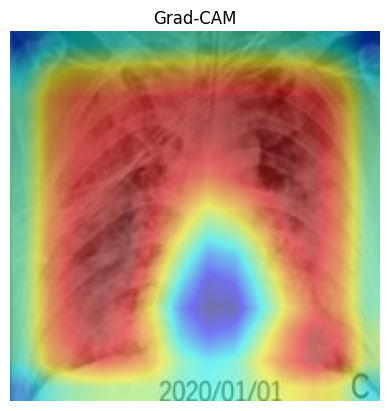

In [83]:
img = input_tensor.squeeze().permute(1,2,0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

In [84]:
import numpy as np
import torch
import torch.nn.functional as F

class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N, s, p1):
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size

        masks = []
        for _ in range(N):
            grid = (np.random.rand(s, s) < p1).astype(float)
            mask = torch.tensor(grid).float()

            mask = F.interpolate(
                mask.unsqueeze(0).unsqueeze(0),
                size=tuple(up_size.astype(int)),
                mode='bilinear',
                align_corners=False
            )

            mask = mask[:, :, :self.input_size[0], :self.input_size[1]]
            masks.append(mask)

        masks = torch.cat(masks, dim=0)
        return masks.to(self.device)

    def explain(self, image, masks, batch_size=16):
        N = masks.size(0)
        _, _, H, W = image.size()

        saliency = torch.zeros((H, W)).to(self.device)

        for i in range(0, N, batch_size):
            batch_masks = masks[i:i+batch_size]
            batch_image = image.repeat(batch_masks.size(0), 1, 1, 1)

            masked = batch_image * batch_masks

            with torch.no_grad():
                preds = self.model(masked)
                probs = torch.softmax(preds, dim=1)
                target_class = preds.argmax(dim=1)

            for j in range(batch_masks.size(0)):
                saliency += probs[j, target_class[j]] * batch_masks[j, 0]

        saliency /= N
        return saliency.cpu().numpy()

In [85]:
_, _, H, W = input_tensor.shape

rise = RISE(model, input_size=(H, W), device=device)

masks = rise.generate_masks(N=500, s=8, p1=0.5)   # safe
saliency_map = rise.explain(input_tensor, masks, batch_size=16)

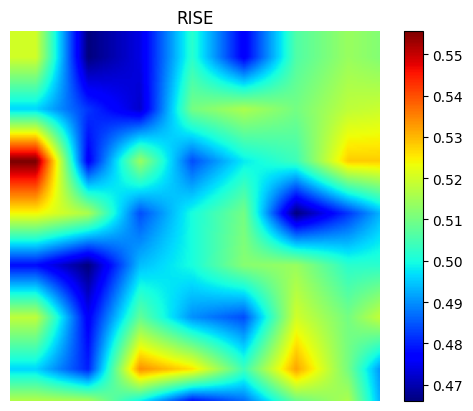

In [86]:
plt.imshow(saliency_map, cmap='jet')
plt.colorbar()
plt.title("RISE")
plt.axis('off')
plt.show()